# 05 - Backtesting V1: baseline operativo inicial

Este notebook implementa la primera evaluación financiera del modelo supervisado sobre DOGE/USDT mediante un backtest operativo sencillo y deliberadamente limitado.

El objetivo no es construir todavía una estrategia robusta, sino comprobar si las probabilidades generadas por el modelo pueden transformarse directamente en decisiones de trading rentables bajo una lógica inicial de ejecución.

Hasta ahora se habían analizado métricas clásicas de clasificación, como accuracy, precision, recall y F1-score. Sin embargo, en un sistema de trading estas métricas no son suficientes. Un modelo puede acertar razonablemente bien la dirección del precio y aun así perder dinero si opera demasiado, si entra tarde, si no controla las pérdidas o si las comisiones consumen el beneficio.

La estrategia V1 utiliza una lógica long-only con exposición completa, probabilidades raw del modelo, Take Profit y Stop Loss porcentuales fijos, comisiones por operación y comparación contra una estrategia pasiva Buy & Hold.

Este diseño permite evaluar una primera hipótesis de trabajo: un baseline predictivo con métricas aceptables no garantiza por sí solo una estrategia financieramente viable.

En este notebook se analiza:

- La evolución de la equity curve de la estrategia
- El drawdown máximo alcanzado
- La comparación frente a Buy & Hold
- La frecuencia de operaciones generadas
- Los motivos principales de salida
- Las limitaciones operativas del baseline inicial


In [1]:
# ============================================================
# Imports and configuration
# En esta celda se importan las librerías necesarias para el backtesting y se definen los parámetros principales de la simulación.
# También se fijan las rutas del modelo XGBoost guardado en el notebook de baseline y del dataset procesado con features.
# Esta versión V1 mantiene una lógica inicial deliberadamente simple: probabilidades raw, exposición completa, TP/SL porcentuales fijos y comisiones activas.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import joblib
from IPython.display import display

# Configuración general del backtest
INITIAL_BALANCE = 1000
FEE_RATE = 0.001          # Comisión por operación: 0.1%
COOLDOWN_BARS = 12        # Número de velas de espera tras cerrar una posición
TP_PCT = 0.03             # Take Profit fijo: +3%
SL_PCT = 0.02             # Stop Loss fijo: -2%
BUY_THRESHOLD = 0.55      # Probabilidad raw mínima para abrir posición
SELL_THRESHOLD = 0.45     # Probabilidad raw para forzar salida

# Modelo principal seleccionado para el baseline operativo inicial
MODEL_PATH = Path("../models/xgboost.joblib")
DATA_PATH = Path("../data/processed/DOGEUSDT_5m_binance_2017_2026_features.csv")


In [2]:
# ============================================================
# Load model and dataset
# En esta sección se carga el modelo XGBoost guardado en el notebook anterior junto con la lista de variables utilizadas durante el entrenamiento.
# El fichero del modelo contiene la estructura guardada en el notebook de baseline: modelo, columnas feature y target.
# Esta estructura permite reutilizar exactamente las mismas variables durante el backtesting, evitando inconsistencias entre entrenamiento y evaluación.
# ============================================================

bundle = joblib.load(MODEL_PATH)

model = bundle["model"]
feature_cols = bundle["feature_cols"]
target = bundle["target"]

print("Modelo cargado correctamente")
print("Target del modelo:", target)
print("Número de features:", len(feature_cols))
print("Tipo de modelo:", type(model))

# Load processed dataset
df = pd.read_csv(DATA_PATH)

# Conversión de fecha si existe la columna temporal
if "open_time" in df.columns:
    df["open_time"] = pd.to_datetime(df["open_time"])

print("Shape del dataset:", df.shape)
df.head()


Modelo cargado correctamente
Target del modelo: up_1
Número de features: 40
Tipo de modelo: <class 'xgboost.sklearn.XGBClassifier'>
Shape del dataset: (723080, 54)


,open_time,open,high,low,close,volume,close_time,quote_asset_volume,number_of_trades,taker_buy_base_asset_volume,...,price_position_in_recent_range,recent_support,recent_resistance,dist_to_nearest_support,dist_to_nearest_resistance,near_support,near_resistance,support_strength,resistance_strength,touch_count_near_level
0,2019-07-06 11:55:00,0.003630,0.003644,0.003630,0.003635,472036.0,2019-07-06 11:59:59.999,1718.044681,24,405943.0,...,0.081048,0.00355,0.004600,0.023411,0.265440,0,0,0.0,0.0,0.0
1,2019-07-06 12:00:00,0.003632,0.003638,0.003629,0.003637,799853.0,2019-07-06 12:04:59.999,2908.008956,18,292138.0,...,0.109846,0.00355,0.004340,0.023867,0.193412,0,0,0.0,0.0,0.0
2,2019-07-06 12:05:00,0.003634,0.003637,0.003625,0.003637,2176492.0,2019-07-06 12:09:59.999,7909.776304,42,1028365.0,...,0.166956,0.00355,0.004069,0.023813,0.118820,0,0,0.0,0.0,0.0
3,2019-07-06 12:10:00,0.003636,0.003636,0.003620,0.003620,618720.0,2019-07-06 12:14:59.999,2240.639784,16,33792.0,...,0.168759,0.00355,0.003964,0.019310,0.095113,0,0,0.0,0.0,0.0
4,2019-07-06 12:15:00,0.003621,0.003627,0.003610,0.003611,1808302.0,2019-07-06 12:19:59.999,6538.506892,30,450314.0,...,0.147272,0.00355,0.003964,0.016893,0.097812,0,0,0.0,0.0,0.0


In [3]:
# ============================================================
# Prepare temporal test set
# Se mantiene una partición cronológica, igual que en los notebooks anteriores.
# En series temporales no debemos mezclar aleatoriamente pasado y futuro, porque eso introduciría leakage temporal.
# La idea es simular una situación realista: el modelo aprende del pasado y se evalúa sobre un periodo posterior no visto durante el entrenamiento.
# ============================================================

# Columnas mínimas necesarias para el backtest
required_cols = feature_cols + ["close"]

# Si existe la variable objetivo usada por el modelo, también la conservamos para posibles análisis posteriores
if target in df.columns:
    required_cols.append(target)

df_model = df.dropna(subset=required_cols).copy()

split_idx = int(len(df_model) * 0.8)
df_train = df_model.iloc[:split_idx].copy()
df_test = df_model.iloc[split_idx:].copy()

print("Train shape:", df_train.shape)
print("Test shape:", df_test.shape)

if "open_time" in df_test.columns:
    print("Periodo de test:")
    print(df_test["open_time"].min(), "->", df_test["open_time"].max())

Train shape: (578464, 54)
Test shape: (144616, 54)
Periodo de test:
2025-01-06 06:55:00 -> 2026-05-23 10:10:00


In [4]:
# ============================================================
# Generate model probabilities
# Para trading resulta más útil trabajar con probabilidades que con una predicción binaria directa.
# Una predicción 0/1 solo indica la clase estimada, mientras que la probabilidad permite aplicar filtros mínimos de confianza.
# En esta versión V1 se utilizan probabilidades raw del modelo, sin smoothing, sin calibración adicional y sin threshold tuning avanzado.
# ============================================================

X_test = df_test[feature_cols]

# Probabilidad de clase 1: subida del precio en el horizonte objetivo
proba_up = model.predict_proba(X_test)[:, 1]

bt_input = df_test.copy().reset_index(drop=True)
bt_input["proba_up"] = proba_up
bt_input["prediction"] = (bt_input["proba_up"] >= 0.5).astype(int)

bt_input[["close", "proba_up", "prediction"]].head()


,close,proba_up,prediction
0,0.38417,0.557037,1
1,0.38310,0.579374,1
2,0.38295,0.560027,1
3,0.38286,0.565750,1
4,0.38148,0.582919,1


In [5]:
# ============================================================
# Backtesting engine
# Esta función simula una estrategia long-only en mercado spot.
# La estrategia empieza con un capital inicial en USDT, solo puede tener una posición abierta y utiliza todo el capital disponible al comprar.
# El motor incorpora comisiones, cooldown básico, Take Profit fijo, Stop Loss fijo y salida por señal raw del modelo, sin position sizing ni adaptación a volatilidad.
# ============================================================

def run_backtest(
    df,
    prob_col="proba_up",
    price_col="close",
    initial_balance=INITIAL_BALANCE,
    fee_rate=FEE_RATE,
    cooldown_bars=COOLDOWN_BARS,
    tp_pct=TP_PCT,
    sl_pct=SL_PCT,
    buy_threshold=BUY_THRESHOLD,
    sell_threshold=SELL_THRESHOLD,
):
    df = df.copy().reset_index(drop=True)

    cash = initial_balance
    position = 0.0
    entry_price = None
    cooldown = 0

    equity_curve = []
    actions = []
    position_values = []
    cash_values = []
    entry_prices = []
    exit_reasons = []

    for _, row in df.iterrows():
        price = row[price_col]
        proba = row[prob_col]

        action = "HOLD"
        exit_reason = None

        if cooldown > 0:
            cooldown -= 1

        # Lógica de salida
        if position > 0:
            pnl_pct = (price - entry_price) / entry_price

            hit_tp = pnl_pct >= tp_pct
            hit_sl = pnl_pct <= -sl_pct
            model_exit = proba < sell_threshold

            if hit_tp or hit_sl or model_exit:
                cash = position * price * (1 - fee_rate)
                position = 0.0
                entry_price = None
                cooldown = cooldown_bars
                action = "SELL"

                if hit_tp:
                    exit_reason = "TP"
                elif hit_sl:
                    exit_reason = "SL"
                else:
                    exit_reason = "MODEL_EXIT"

        # Lógica de entrada
        elif cooldown == 0 and proba > buy_threshold:
            position = (cash * (1 - fee_rate)) / price
            cash = 0.0
            entry_price = price
            action = "BUY"

        equity = cash + position * price

        equity_curve.append(equity)
        actions.append(action)
        position_values.append(position * price)
        cash_values.append(cash)
        entry_prices.append(entry_price)
        exit_reasons.append(exit_reason)

    df["equity"] = equity_curve
    df["action"] = actions
    df["position_value"] = position_values
    df["cash"] = cash_values
    df["entry_price"] = entry_prices
    df["exit_reason"] = exit_reasons

    df["strategy_return"] = df["equity"].pct_change().fillna(0)
    df["equity_cummax"] = df["equity"].cummax()
    df["drawdown"] = (df["equity"] / df["equity_cummax"]) - 1

    return df


In [6]:
# ============================================================
# Buy and Hold benchmark
# Esta función calcula el rendimiento de una estrategia pasiva de Buy & Hold.
# El benchmark compra DOGE al inicio del periodo de test y mantiene la posición hasta el final.
# Esta comparación es imprescindible porque una estrategia activa no solo debe ganar dinero, también debería justificar que aporta valor frente a comprar y esperar.
# ============================================================

def add_buy_and_hold(df, price_col="close", initial_balance=INITIAL_BALANCE, fee_rate=FEE_RATE):
    df = df.copy().reset_index(drop=True)

    first_price = df.loc[0, price_col]
    units = (initial_balance * (1 - fee_rate)) / first_price

    df["buy_hold_equity"] = units * df[price_col]
    df["buy_hold_return"] = df["buy_hold_equity"].pct_change().fillna(0)
    df["buy_hold_cummax"] = df["buy_hold_equity"].cummax()
    df["buy_hold_drawdown"] = (df["buy_hold_equity"] / df["buy_hold_cummax"]) - 1

    return df

In [7]:
# ============================================================
# Run backtest
# En esta celda se ejecuta la estrategia V1 sobre el conjunto de test y se añade la comparación con Buy & Hold.
# El resultado es un dataframe enriquecido con equity, drawdown, acciones realizadas y motivo de salida de cada operación.
# Estas columnas permiten analizar tanto el rendimiento financiero como el comportamiento operativo del baseline inicial.
# ============================================================

bt = run_backtest(bt_input)
bt = add_buy_and_hold(bt)

display(bt[["close", "proba_up", "action", "exit_reason", "equity", "drawdown", "buy_hold_equity", "buy_hold_drawdown"]].head())

print("Action counts:")
display(bt["action"].value_counts())

print("Exit reason counts:")
display(bt["exit_reason"].value_counts(dropna=False))


,close,proba_up,action,exit_reason,equity,drawdown,buy_hold_equity,buy_hold_drawdown
0,0.38417,0.557037,BUY,None,999.000000,0.000000,999.000000,0.000000
1,0.38310,0.579374,HOLD,None,996.217560,-0.002785,996.217560,-0.002785
2,0.38295,0.560027,HOLD,None,995.827498,-0.003176,995.827498,-0.003176
3,0.38286,0.565750,HOLD,None,995.593461,-0.003410,995.593461,-0.003410
4,0.38148,0.582919,HOLD,None,992.004894,-0.007002,992.004894,-0.007002


Action counts:


action
HOLD    142314
BUY       1151
SELL      1151
Name: count, dtype: int64

Exit reason counts:


exit_reason
None          143465
MODEL_EXIT       816
SL               304
TP                31
Name: count, dtype: int64

### Interpretación de los motivos de salida

La mayoría de los cierres de posición se producen mediante señales de salida generadas por el propio modelo (`MODEL_EXIT`), mientras que los eventos de Take Profit son muy poco frecuentes.

En la ejecución actual se observan muchos más Stop Loss que Take Profit, lo que indica que la estrategia entra con frecuencia en movimientos que no alcanzan suficiente recorrido alcista antes de deteriorarse. Este patrón es especialmente problemático porque cada operación incorpora comisiones y utiliza exposición completa del capital disponible.

El bajo número de operaciones cerradas por Take Profit sugiere que el modelo puede detectar algunos rebotes locales, pero no captura movimientos alcistas suficientemente amplios como para compensar pérdidas, costes de transacción y ruido de mercado.

Este comportamiento encaja con la función de este notebook: documentar que una traducción directa de probabilidades del modelo a órdenes de mercado produce una estrategia financieramente débil.


In [8]:
# ============================================================
# Summary metrics
# Esta sección calcula métricas financieras para comparar la estrategia activa contra Buy & Hold de forma compacta.
# Se analizan balance final, rentabilidad total, drawdown máximo, número de operaciones y Sharpe aproximado.
# El Sharpe se calcula sobre retornos de velas de 5 minutos, anualizando con 365 * 24 * 12, ya que hay 12 velas de 5 minutos por hora.
# ============================================================

def summarize_strategy(bt, equity_col="equity", return_col="strategy_return", drawdown_col="drawdown"):
    final_balance = bt[equity_col].iloc[-1]
    total_return = final_balance / INITIAL_BALANCE - 1
    max_drawdown = bt[drawdown_col].min()

    trades = bt[bt["action"].isin(["BUY", "SELL"])]
    num_buys = (bt["action"] == "BUY").sum()
    num_sells = (bt["action"] == "SELL").sum()

    returns_std = bt[return_col].std()
    sharpe_approx = (
        bt[return_col].mean() / returns_std * np.sqrt(365 * 24 * 12)
        if returns_std != 0
        else np.nan
    )

    return pd.Series({
        "final_balance": final_balance,
        "total_return_%": total_return * 100,
        "max_drawdown_%": max_drawdown * 100,
        "num_trades": len(trades),
        "num_buys": num_buys,
        "num_sells": num_sells,
        "sharpe_approx": sharpe_approx,
    })


def summarize_buy_hold(bt):
    final_balance = bt["buy_hold_equity"].iloc[-1]
    total_return = final_balance / INITIAL_BALANCE - 1
    max_drawdown = bt["buy_hold_drawdown"].min()

    returns_std = bt["buy_hold_return"].std()
    sharpe_approx = (
        bt["buy_hold_return"].mean() / returns_std * np.sqrt(365 * 24 * 12)
        if returns_std != 0
        else np.nan
    )

    return pd.Series({
        "final_balance": final_balance,
        "total_return_%": total_return * 100,
        "max_drawdown_%": max_drawdown * 100,
        "num_trades": 1,
        "num_buys": 1,
        "num_sells": 0,
        "sharpe_approx": sharpe_approx,
    })

summary = pd.DataFrame({
    "Strategy": summarize_strategy(bt),
    "Buy & Hold": summarize_buy_hold(bt),
}).T

summary

,final_balance,total_return_%,max_drawdown_%,num_trades,num_buys,num_sells,sharpe_approx
Strategy,69.392160,-93.060784,-93.165196,2302.0,1151.0,1151.0,-3.855822
Buy & Hold,258.870943,-74.112906,-81.410760,1.0,1.0,0.0,-0.463751


### Interpretación de las métricas agregadas

La tabla de métricas resume el principal problema del baseline V1: la estrategia activa termina con un balance final muy inferior al capital inicial y también peor que Buy & Hold.

En la ejecución registrada, la estrategia finaliza cerca de 69 USDT desde un capital inicial de 1000 USDT, lo que implica una pérdida aproximada del 93%. Buy & Hold también pierde valor de forma significativa, pero conserva alrededor de 259 USDT, con una pérdida aproximada del 74%.

La diferencia es relevante porque el sistema activo no solo no evita el régimen bajista, sino que además lo empeora mediante entradas y salidas frecuentes, exposición completa y costes de transacción acumulados.

El número elevado de operaciones confirma un problema de sobreoperación. Aunque existe un cooldown básico tras cada salida, la estrategia sigue generando demasiadas operaciones para un entorno dominado por ruido y presión bajista.

Estos resultados refuerzan una conclusión central del proyecto: unas métricas de clasificación aceptables no bastan para validar una estrategia de trading si la capa de ejecución y gestión de riesgo es demasiado ingenua.


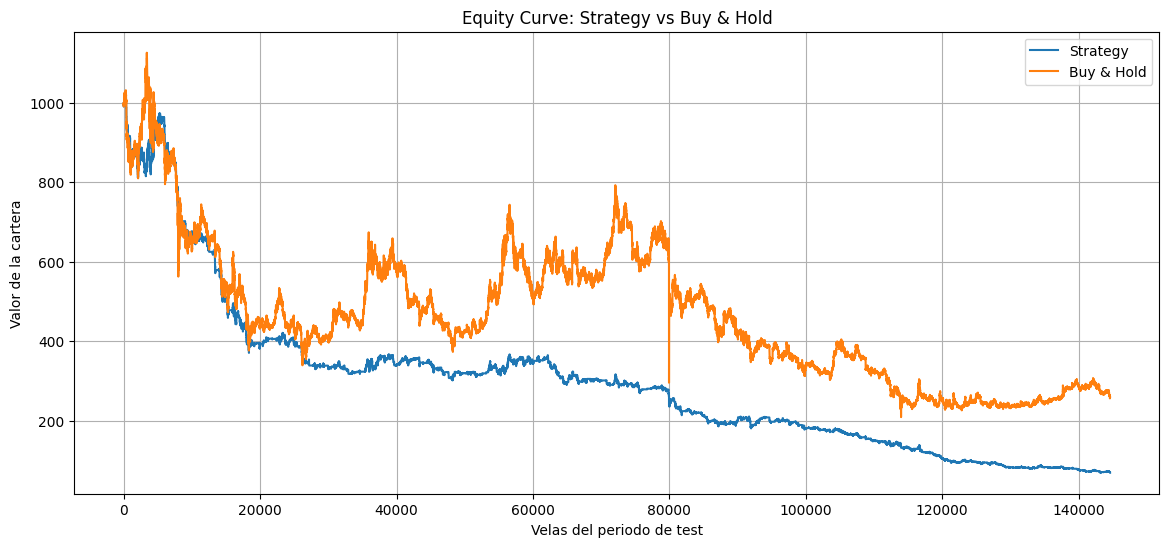

In [9]:
# ============================================================
# Equity curve comparison
# Esta visualización compara la evolución del valor de la cartera de la estrategia frente al benchmark Buy & Hold.
# La curva de equity permite observar si la estrategia crece de forma estable, si atraviesa periodos laterales o si sufre caídas relevantes.
# Esta gráfica es una de las más importantes para interpretar el comportamiento financiero del sistema.
# ============================================================

plt.figure(figsize=(14, 6))
plt.plot(bt["equity"], label="Strategy")
plt.plot(bt["buy_hold_equity"], label="Buy & Hold")
plt.title("Equity Curve: Strategy vs Buy & Hold")
plt.xlabel("Velas del periodo de test")
plt.ylabel("Valor de la cartera")
plt.legend()
plt.grid(True)
plt.show()

### Interpretación de la curva de equity

La curva de equity muestra que tanto la estrategia activa como el benchmark Buy & Hold sufren una pérdida significativa de valor durante el periodo de test. Esto sugiere que el conjunto evaluado corresponde a un régimen de mercado predominantemente bajista, caracterizado por caídas prolongadas y elevada presión vendedora.

La estrategia basada en XGBoost no consigue mejorar al benchmark pasivo. Aunque puede evitar parcialmente algunos tramos concretos, termina destruyendo más capital que Buy & Hold debido a la combinación de exposición completa, entradas frecuentes, salidas reactivas y comisiones acumuladas.

Este resultado es especialmente importante porque invalida una lectura superficial de las métricas predictivas. El modelo puede asignar probabilidades aparentemente útiles en algunos momentos, pero la estrategia V1 no transforma esas señales en una curva de capital defendible.

La equity curve confirma que el problema no es un fallo puntual de una operación concreta, sino un deterioro sistemático del capital durante el periodo de evaluación.


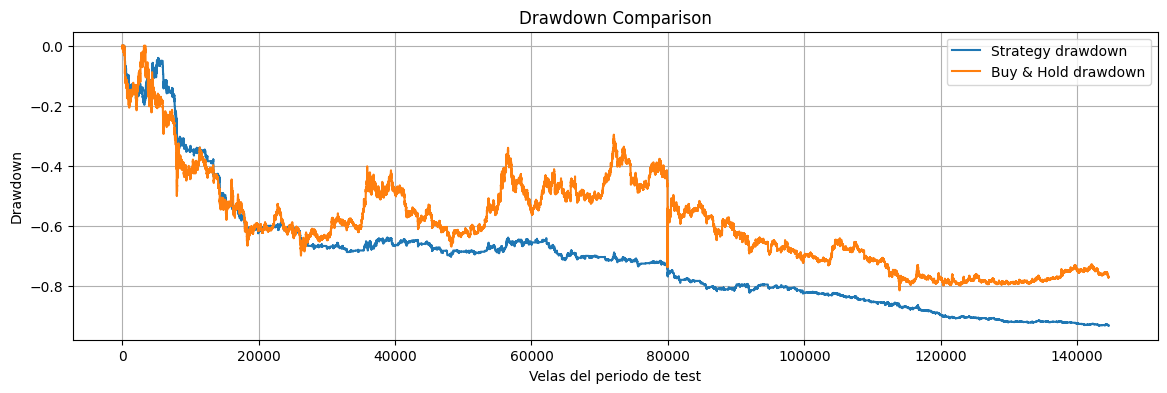

In [10]:
# ============================================================
# Drawdown comparison
# Esta visualización muestra la caída porcentual desde el máximo acumulado de cada estrategia.
# El drawdown permite evaluar el riesgo asumido, no solo la rentabilidad final.
# En trading, una estrategia rentable puede no ser aceptable si durante el camino sufre pérdidas intermedias demasiado elevadas.
# ============================================================

plt.figure(figsize=(14, 4))
plt.plot(bt["drawdown"], label="Strategy drawdown")
plt.plot(bt["buy_hold_drawdown"], label="Buy & Hold drawdown")
plt.title("Drawdown Comparison")
plt.xlabel("Velas del periodo de test")
plt.ylabel("Drawdown")
plt.legend()
plt.grid(True)
plt.show()

### Interpretación del drawdown

El gráfico de drawdown confirma que ambas estrategias atraviesan periodos de pérdidas profundas durante el conjunto de test. Sin embargo, la estrategia basada en machine learning presenta un drawdown máximo incluso más severo que el benchmark Buy & Hold.

En la ejecución actual, el drawdown máximo de la estrategia se sitúa en torno al 93%, frente a un drawdown aproximado del 81% para Buy & Hold. Esta diferencia indica que el sistema no consigue proteger adecuadamente el capital en fases prolongadas de tendencia bajista.

Aunque el Stop Loss limita algunas pérdidas individuales, no resuelve el problema agregado. La estrategia vuelve a entrar repetidamente en el mercado con exposición completa, de modo que muchas pérdidas pequeñas y medianas terminan acumulándose en una pérdida total muy elevada.

El drawdown extremo refleja una limitación crítica del baseline V1: la estrategia long-only no incorpora todavía filtros de régimen, control dinámico de exposición ni adaptación del riesgo a la volatilidad.


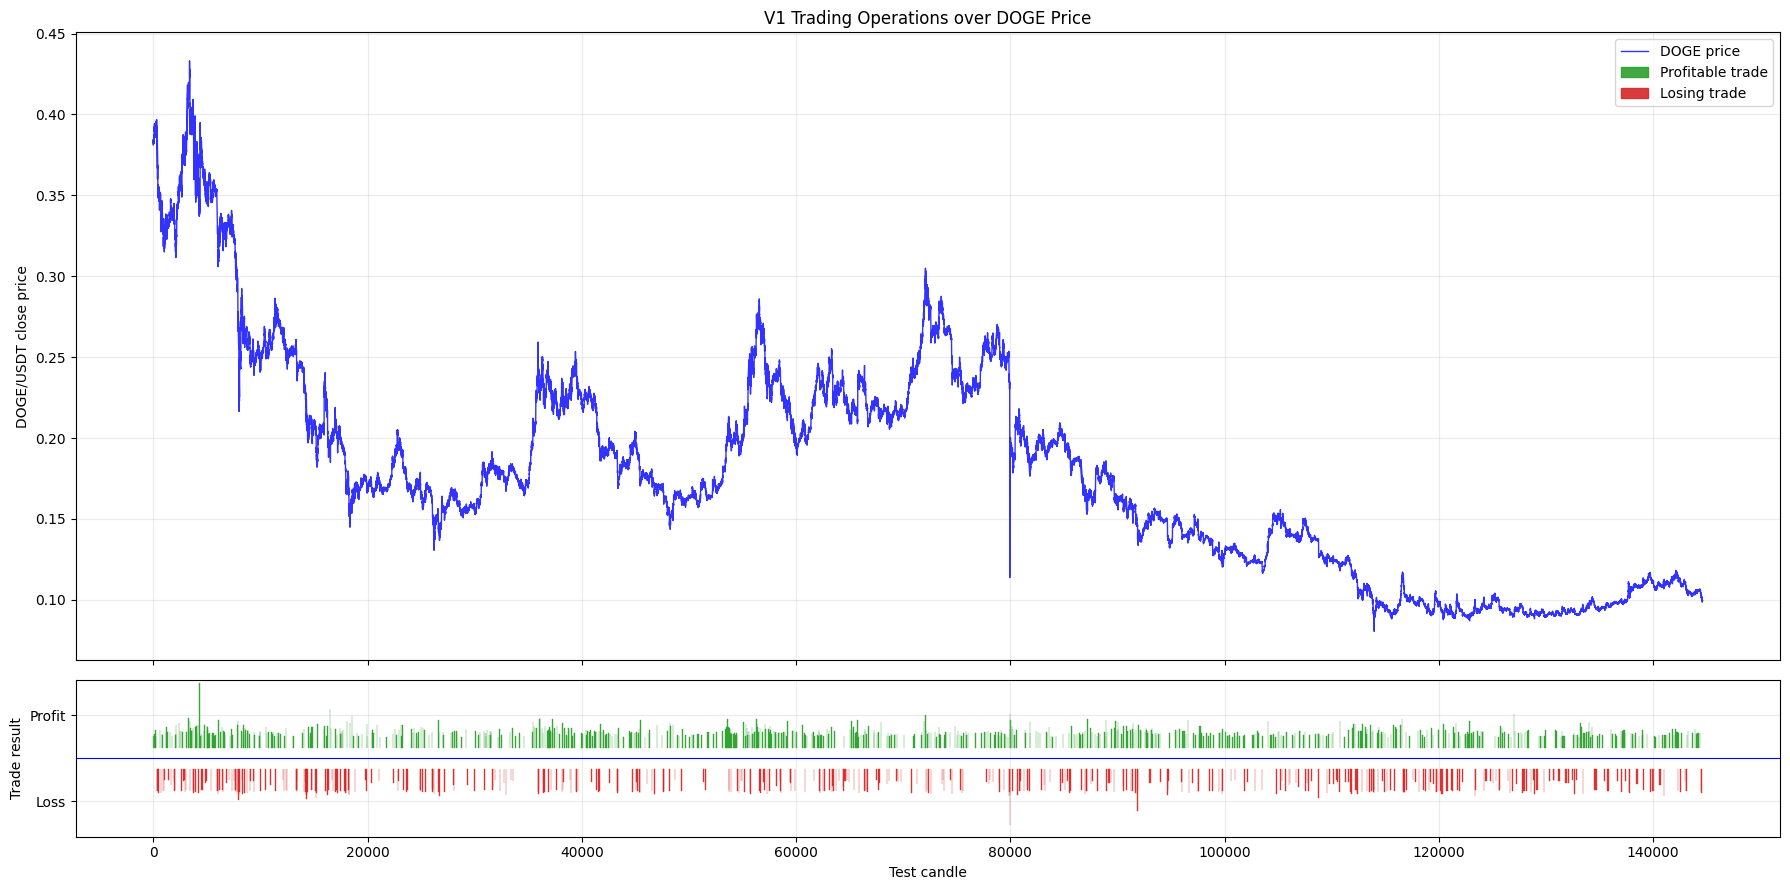

,entry_idx,exit_idx,entry_price,exit_price,pnl_pct,duration_bars,result
0,0,34,0.38417,0.38464,0.122342,34,PROFIT
1,70,83,0.38568,0.38655,0.225576,13,PROFIT
2,118,139,0.38752,0.38959,0.534166,21,PROFIT
3,166,187,0.38781,0.38814,0.085093,21,PROFIT
4,218,221,0.38683,0.39156,1.222759,3,PROFIT
...,...,...,...,...,...,...,...
1146,144031,144125,0.10540,0.10600,0.569260,94,PROFIT
1147,144143,144322,0.10502,0.10572,0.666540,179,PROFIT
1148,144376,144391,0.10555,0.10631,0.720038,15,PROFIT
1149,144429,144490,0.10435,0.10204,-2.213704,61,LOSS


In [11]:
# ============================================================
# Trading operations timeline
# Se visualizan las operaciones completas de la estrategia V1 sobre el precio de DOGE.
# El panel superior muestra la serie de precios y el panel inferior representa cada trade como un bloque temporal.
# Las operaciones rentables aparecen sobre la línea central y las perdedoras por debajo.
# ============================================================

import matplotlib.patches as patches

plot_df = bt.copy().reset_index(drop=True)

trade_rows = []

position_open = False
entry_idx = None
entry_price = None

for i, row in plot_df.iterrows():
    action = row["action"]
    price_i = float(row["close"])

    if action == "BUY" and not position_open:
        position_open = True
        entry_idx = i
        entry_price = price_i

    elif action == "SELL" and position_open:
        exit_idx = i
        exit_price = price_i

        pnl_pct = (exit_price / entry_price - 1) * 100

        trade_rows.append({
            "entry_idx": entry_idx,
            "exit_idx": exit_idx,
            "entry_price": entry_price,
            "exit_price": exit_price,
            "pnl_pct": pnl_pct,
            "duration_bars": exit_idx - entry_idx,
            "result": "PROFIT" if pnl_pct >= 0 else "LOSS"
        })

        position_open = False
        entry_idx = None
        entry_price = None

trades_df = pd.DataFrame(trade_rows)

price = plot_df["close"].astype(float).reset_index(drop=True)
x = np.arange(len(price))

fig, (ax_price, ax_trades) = plt.subplots(
    2,
    1,
    figsize=(18, 9),
    sharex=True,
    gridspec_kw={"height_ratios": [4, 1]}
)

# ============================================================
# Price series
# ============================================================

ax_price.plot(
    x,
    price,
    color="blue",
    linewidth=1.0,
    alpha=0.8,
    label="DOGE price"
)

ax_price.set_title("V1 Trading Operations over DOGE Price")
ax_price.set_ylabel("DOGE/USDT close price")
ax_price.grid(alpha=0.25)

# ============================================================
# Trade activity blocks
# ============================================================

if not trades_df.empty:

    max_abs_pnl = max(trades_df["pnl_pct"].abs().max(), 1e-9)

    for _, trade in trades_df.iterrows():

        entry_idx = int(trade["entry_idx"])
        exit_idx = int(trade["exit_idx"])

        actual_width = max(exit_idx - entry_idx, 1)
        visual_width = max(actual_width, 45)

        x_start = entry_idx - (visual_width - actual_width) / 2

        pnl_scaled = abs(trade["pnl_pct"]) / max_abs_pnl
        height = 0.15 + pnl_scaled * 0.75

        if trade["result"] == "PROFIT":
            y_base = 0.15
            color = "tab:green"
            label = "Profitable trade"

        else:
            y_base = -0.15 - height
            color = "tab:red"
            label = "Losing trade"

        rect = patches.Rectangle(
            (x_start, y_base),
            visual_width,
            height,
            linewidth=0.3,
            edgecolor=color,
            facecolor=color,
            alpha=0.9
        )

        ax_trades.add_patch(rect)

ax_trades.axhline(0, color="blue", linewidth=0.8)

ax_trades.set_ylim(-1.1, 1.1)

ax_trades.set_ylabel("Trade result")
ax_trades.set_xlabel("Test candle")

ax_trades.set_yticks([-0.6, 0.6])
ax_trades.set_yticklabels(["Loss", "Profit"])

ax_trades.grid(alpha=0.25)

legend_handles = [
    patches.Patch(facecolor="tab:green", edgecolor="tab:green", alpha=0.9, label="Profitable trade"),
    patches.Patch(facecolor="tab:red", edgecolor="tab:red", alpha=0.9, label="Losing trade"),
]

ax_price.legend(
    handles=[ax_price.get_legend_handles_labels()[0][0]] + legend_handles,
    loc="upper right"
)

plt.tight_layout()
plt.show()

display(trades_df)

### Interpretación de las operaciones sobre el precio

La representación de compras y ventas sobre la serie temporal permite observar que el sistema genera señales de entrada y salida de forma frecuente a lo largo del periodo de test.

La mayoría de las operaciones siguen pequeños movimientos locales del precio, pero el contexto general continúa siendo bajista. Esto provoca que muchas entradas long terminen atrapadas dentro de una tendencia descendente de mayor escala.

También puede observarse que la estrategia permanece activa incluso durante fases donde el mercado muestra debilidad sostenida. Esto sugiere que el modelo es capaz de detectar rebotes de corto plazo, pero no distingue adecuadamente entre movimientos temporales y cambios reales de tendencia.

Este patrón justifica la necesidad de una segunda versión del backtest centrada en mejoras operativas, como suavizado de probabilidades, control de exposición y niveles de salida adaptados a la volatilidad.


# Conclusión

En este notebook se ha evaluado el modelo XGBoost como parte de una primera estrategia de trading simulada sobre DOGE/USDT. A diferencia de la evaluación mediante métricas de clasificación, el backtesting permite analizar el comportamiento financiero del sistema bajo condiciones más cercanas a un escenario operativo.

La estrategia V1 incorpora comisiones, reglas de entrada y salida, cooldown básico, Take Profit fijo, Stop Loss fijo y comparación contra una estrategia pasiva Buy & Hold. Sin embargo, mantiene decisiones deliberadamente simples: opera solo en long, utiliza probabilidades raw del modelo, invierte el capital completo disponible en cada entrada y no adapta los niveles de salida a la volatilidad del mercado.

Los resultados muestran una limitación importante del sistema inicial. Durante el periodo de test, el mercado presenta un comportamiento predominantemente bajista, caracterizado por caídas prolongadas y rebotes alcistas débiles. En este contexto, el modelo consigue detectar algunos movimientos positivos de corto plazo, pero la tendencia general del mercado termina dominando el comportamiento de la cartera.

La estrategia activa obtiene un resultado peor que Buy & Hold. Esto es especialmente relevante porque Buy & Hold también sufre pérdidas importantes durante el periodo evaluado, pero preserva más capital que el sistema basado en señales del modelo. Por tanto, la estrategia V1 no aporta valor financiero frente al benchmark pasivo.

El drawdown elevado confirma que el problema no se limita a una baja rentabilidad final. La estrategia atraviesa pérdidas profundas y persistentes, lo que la haría difícilmente aceptable en un entorno operativo real. La combinación de exposición completa, sobreoperación, comisiones acumuladas y ausencia de filtro de régimen deteriora progresivamente el capital.

La principal conclusión del notebook es que una buena evaluación predictiva no garantiza una estrategia de trading rentable. En mercados financieros, la capa de ejecución, la gestión del riesgo, el control de exposición y la adaptación al régimen de mercado son componentes críticos del sistema.

Este V1 debe interpretarse como un baseline operativo inicial. Su utilidad dentro del proyecto no reside en ofrecer una estrategia final, sino en demostrar de forma trazable las limitaciones de una implementación ingenua y justificar las mejoras de las versiones posteriores.

A partir de estos resultados, la siguiente evolución del sistema debe centrarse en mejoras operativas antes de modificar el modelo predictivo:

- Suavizar probabilidades para reducir ruido en las señales
- Sustituir TP/SL fijos por niveles adaptados a volatilidad
- Limitar el tamaño de posición para reducir exposición
- Reducir la sobreoperación
- Mantener comisiones en la simulación
- Comparar explícitamente la nueva versión contra V1 y Buy & Hold

De este modo, el proyecto conserva una evolución metodológica clara: primero se documenta el fallo del baseline inicial y después se introducen mejoras justificadas por evidencia empírica.


In [12]:
# ============================================================
# Save V1 backtesting results
# Se guarda un resumen comparable del backtest V1 y una copia detallada de la simulación para reutilizar estos resultados en notebooks posteriores.
# ============================================================

RESULTS_DIR = Path("../results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

strategy_summary = summary.loc["Strategy"].to_dict()
buy_hold_summary = summary.loc["Buy & Hold"].to_dict()

results_summary = {
    "notebook": "05_backtesting_v1",
    "strategy": "Long-only supervised model with raw probabilities, full exposure and fixed TP/SL",
    "initial_balance": INITIAL_BALANCE,
    "final_balance": strategy_summary["final_balance"],
    "return_pct": strategy_summary["total_return_%"],
    "buy_and_hold_final_balance": buy_hold_summary["final_balance"],
    "buy_and_hold_return_pct": buy_hold_summary["total_return_%"],
    "max_drawdown_pct": strategy_summary["max_drawdown_%"],
    "buy_and_hold_max_drawdown_pct": buy_hold_summary["max_drawdown_%"],
    "sharpe_ratio": strategy_summary["sharpe_approx"],
    "buy_and_hold_sharpe_ratio": buy_hold_summary["sharpe_approx"],
    "num_trades": strategy_summary["num_trades"],
    "buy_signals": strategy_summary["num_buys"],
    "sell_signals": strategy_summary["num_sells"],
    "hold_signals": int((bt["action"] == "HOLD").sum()),
    "fees_applied": True,
    "fee_rate": FEE_RATE,
    "slippage_applied": False,
    "position_sizing": "Full exposure",
    "max_position_size": 1.0,
    "probability_handling": "Raw probabilities",
    "tp_sl_method": "Fixed percentage TP/SL",
    "take_profit_pct": TP_PCT * 100,
    "stop_loss_pct": SL_PCT * 100,
    "buy_threshold": BUY_THRESHOLD,
    "sell_threshold": SELL_THRESHOLD,
    "cooldown_bars": COOLDOWN_BARS,
    "main_limitation": "Long-only baseline with full exposure, raw probabilities, fixed TP/SL and high overtrading"
}

results_summary_df = pd.DataFrame([results_summary])

summary_path = RESULTS_DIR / "05_backtesting_v1_summary.csv"
detail_path = RESULTS_DIR / "05_backtesting_v1_backtest.csv"

results_summary_df.to_csv(summary_path, index=False)
bt.to_csv(detail_path, index=False)

print(f"Summary saved to: {summary_path}")
print(f"Detailed backtest saved to: {detail_path}")

display(results_summary_df)

Summary saved to: ..\results\05_backtesting_v1_summary.csv
Detailed backtest saved to: ..\results\05_backtesting_v1_backtest.csv


,notebook,strategy,initial_balance,final_balance,return_pct,buy_and_hold_final_balance,buy_and_hold_return_pct,max_drawdown_pct,buy_and_hold_max_drawdown_pct,sharpe_ratio,...,position_sizing,max_position_size,probability_handling,tp_sl_method,take_profit_pct,stop_loss_pct,buy_threshold,sell_threshold,cooldown_bars,main_limitation
0,05_backtesting_v1,Long-only supervised model with raw probabilit...,1000,69.39216,-93.060784,258.870943,-74.112906,-93.165196,-81.41076,-3.855822,...,Full exposure,1.0,Raw probabilities,Fixed percentage TP/SL,3.0,2.0,0.55,0.45,12,"Long-only baseline with full exposure, raw pro..."
